# Building multilayer neural network

Imported from backpropagation notebook

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        # add backward function
        self._backward = lambda: None

    def __repr__(self) -> str:
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        # to accept other as int as well as Value
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        # to accept other as int as well as Value
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out
    
    # with __mul__ Value * int works but int * Value does not. this swaps so, int * Value becomes Value * int
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other): # self/other
        return self * other**-1
    
    def __pow__(self, other): # self^other
        assert isinstance(other, (int, float)) # for now support int and float
        out = Value(self.data**other, (self,), f'**{other}')
    
        def _backward():
            self.grad = other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out
    
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        other.data = -other.data
        
        return self + (other.data)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) 
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad = out.data * out.grad
        
        out._backward = _backward
        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    # dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [2]:
import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        # w *x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    
    def __init__(self, nin, nout) -> None:
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neurons in self.neurons for p in neurons.parameters()]
    
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(data=0.9605547723335216),
 Value(data=0.7611377481895594),
 Value(data=0.9837241295207377)]

In [3]:

class MLP:

    def __init__(self, nin, nouts) -> None:
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.01585763208589915)

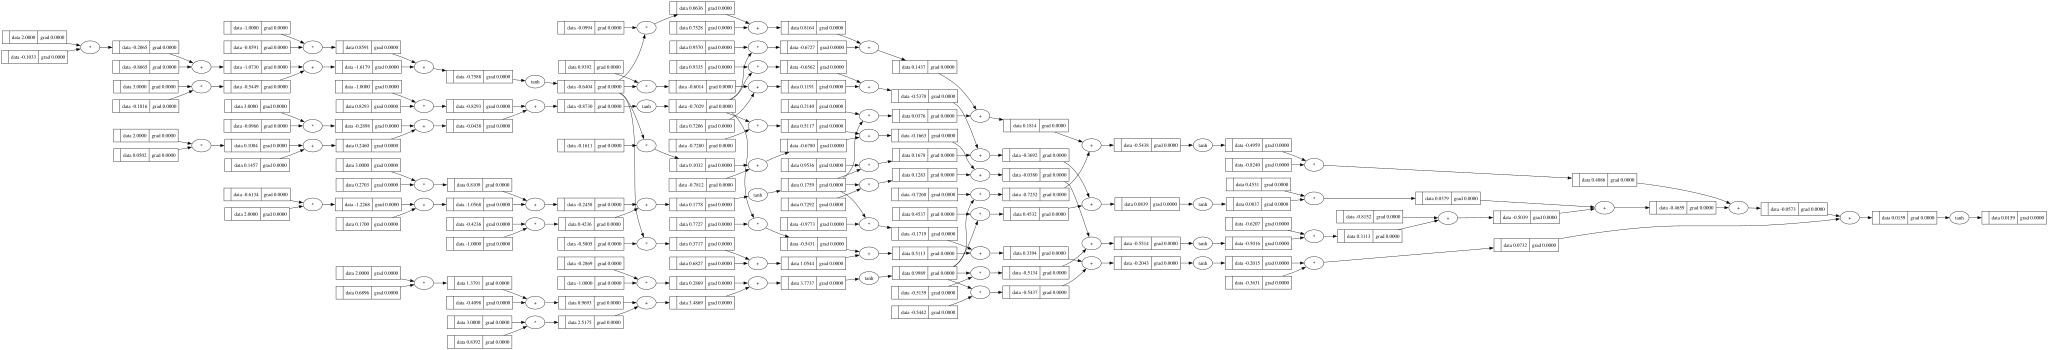

In [4]:
draw_dot(n(x))

In [5]:
# data definition
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs] # predictions
ypred

[Value(data=0.01585763208589915),
 Value(data=-0.8348717403027861),
 Value(data=0.15224426301633637)]

In [6]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.323470384128264)

In [7]:
loss.backward()

In [8]:
n.layers[0].neurons[0].w[0].grad

-0.3679396407374915

In [9]:
n.layers[0].neurons[0].w[0].data

-0.10326302697305167

In [10]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [11]:
# here the data should go down bit as we are minimizing loss and gradient is negative
n.layers[0].neurons[0].w[0].data

-0.09958363056567676

In [12]:
# recalculating loss. It should go down from above.
ypred = [n(x) for x in xs] # predictions
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.2479166516097457)

In [13]:
# if we keep repeating, it should keep going down 

# forward pass -> backward pass -> update

# 2nd pass
loss.backward()

for p in n.parameters():
    p.data += -0.01 * p.grad

ypred = [n(x) for x in xs] # predictions
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
print(loss)

# 3rd pass
loss.backward()

for p in n.parameters():
    p.data += -0.01 * p.grad

ypred = [n(x) for x in xs] # predictions
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
print(loss)

# 4th pass
loss.backward()

for p in n.parameters():
    p.data += -0.01 * p.grad

ypred = [n(x) for x in xs] # predictions
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
print(loss)

# this is gradient decent


Value(data=2.1174736176577786)
Value(data=1.960790857076467)
Value(data=1.7962869547245552)


In [14]:
# in the end predictions ypred should be equal/almost equal to ys
print(ypred)
print(ys)

[Value(data=0.10123357599204592), Value(data=-0.8654379265930428), Value(data=-0.01491172060523899)]
[1.0, -1.0, -1.0, 1.0]


In [15]:
# doing it all together

# data 
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [1.0, 1.0, -1.0],
]
n = MLP(3, [4, 4, 1])

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
learning_rate = -0.15

for k in range(10):

    # forward pass
    ypred = [n(x) for x in xs] # predictions
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # reset grad to 0
    for p in n.parameters():
        p.grad = 0.0

    # backward pass
    loss.backward()

    # update
    for p in n.parameters():
        p.data += learning_rate * p.grad
    
    print(k, loss.data)

for i in range(len(ypred)):
    print(ypred[i], ys[i])

0 3.1535715118806245
1 3.227220796558395
2 1.644966024681009
3 1.5688234455699068
4 3.6929026586731766
5 1.7286278965444455
6 2.5952802176052514
7 2.1257399485703043
8 3.4847477342907998
9 2.5011398458780367
Value(data=0.7215319569822718) 1.0
Value(data=-0.9348022546283699) -1.0
Value(data=0.5554242665248507) -1.0
